# Sentence sentiment score aggregation #2

Testing different aggregation methods (average, mean, etc), as well as investigating some key characteristics of the dataset (e.g., dispersion of the sentence sentiment scores within the utterance)

Methods (in addition to mean and median):
- sentence count
- sentence length (words)
- sentence length (characters)
- LinearSVR
- Random Forest

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../Datasets/Development_data.csv', encoding='utf-8')
len(df)

9068

Removing one- and two-sentence utterances to not influence the aggregation calculations 

In [3]:
sentence_count = df.groupby('ID').size()

one_sentence = (sentence_count == 1).sum()
two_sentence = (sentence_count == 2).sum()

print('No. of one-sentence utterances: ', one_sentence)
print('No. of one-sentence utterances: ', two_sentence)

df1 = df[df["ID"].isin(sentence_count[sentence_count >= 3].index)]
print(len(df1))

check = df1['ID'].unique()
print(len(check))
df1.head()

No. of one-sentence utterances:  107
No. of one-sentence utterances:  145
8671
548


,ID,sent_id,text_utt,text_sent,text_en,chair,annotation_utt,annotation_utt_score,annotation_sent,metadata
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.se...,"Ni replike na repliko. Gospa ministrica, potem...",Ni replike na repliko.,There's no replica to the replica.,True,N_Neutral,2.0,2.240412,{'Text_ID': 'ParlaMint-SI-en_2010-09-07-SDZ5-I...
1,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.se...,"Ni replike na repliko. Gospa ministrica, potem...","Gospa ministrica, potem se boste lahko javili,...","Madam Minister, you'll be able to come forward...",True,N_Neutral,2.0,2.636969,{'Text_ID': 'ParlaMint-SI-en_2010-09-07-SDZ5-I...
2,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.se...,"Ni replike na repliko. Gospa ministrica, potem...",Besedo pa ima gospod Gorenak.,Mr. Gorenak has the floor.,True,N_Neutral,2.0,3.639261,{'Text_ID': 'ParlaMint-SI-en_2010-09-07-SDZ5-I...
3,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.seg3...,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,Hvala lepa.,Thank you very much.,True,P_Neutral,3.0,4.084590,{'Text_ID': 'ParlaMint-SI-en_2011-06-16-SDZ5-R...
4,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.seg3...,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,Besedo ima Silva Črnugelj.,"The word is ""silva blackugelj.""",True,P_Neutral,3.0,3.340636,{'Text_ID': 'ParlaMint-SI-en_2011-06-16-SDZ5-R...


## Sentence-count based avg

Average based on calculation of no. of sentences in one full utterance

In [4]:
df1.loc[:, 'count'] = df1.groupby('ID')['sent_id'].transform('count')
count_avg = (
    df1.groupby('ID', group_keys=True)
    .apply(lambda x: (x['annotation_sent'] * x['count']).sum() / x['count'].sum())
    .reset_index(name='count_avg')
)

df1 = df1.merge(count_avg, on='ID')

df1["count_avg"] = df1["count_avg"].round(2)
df_count = df1.drop_duplicates(subset=['ID']).reset_index()

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(df_count['annotation_utt_score'], df_count['count_avg'])
print(f"Mean Absolute Error (MAE): {mae}")

/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1670/1216435149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.loc[:, 'count'] = df1.groupby('ID')['sent_id'].transform('count')
/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1670/1216435149.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1.groupby('ID', group_keys=True)


Mean Absolute Error (MAE): 1.2387591240875913


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1670/2050493690.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="annotation_utt_score", y="count_avg", data=df_count, palette='muted')


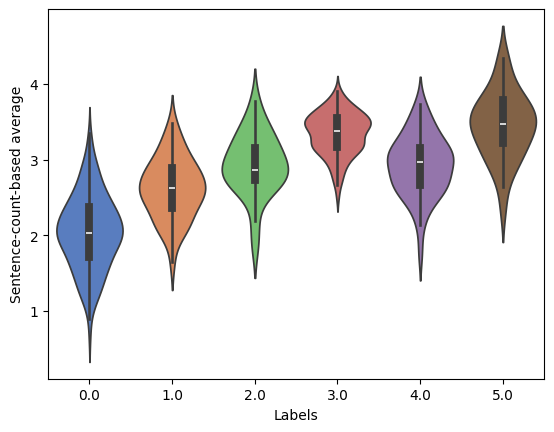

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x="annotation_utt_score", y="count_avg", data=df_count, palette='muted')
plt.xlabel("Labels")
plt.ylabel("Sentence-count-based average")
plt.show()

## Word-based length avg

Average based on calculation of no. of words in individual sentences

In [6]:
df1["words"] = df1["text_sent"].apply(lambda x: len(x.split()))

# Compute the sentence-length-weighted average for each utterance
word_weighted_avg = (
    df1.groupby("ID")
    .apply(lambda group: (group["annotation_sent"] * group["words"]).sum() / group["words"].sum())
    .reset_index(name="word_avg")
)

# Add the length_avg back to the filtered DataFrame
df1 = df1.merge(word_weighted_avg, on="ID")

df1["word_avg"] = df1["word_avg"].round(2)
df_word = df1.drop_duplicates(subset=['ID']).reset_index()

mae = mean_absolute_error(df_word['annotation_utt_score'], df_word['word_avg'])
print(f"Mean Absolute Error (MAE): {mae}")

Mean Absolute Error (MAE): 1.051259124087591


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1670/825075954.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1.groupby("ID")


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_3375/224956828.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="annotation_utt", y="word_avg", data=df_word, palette='muted')


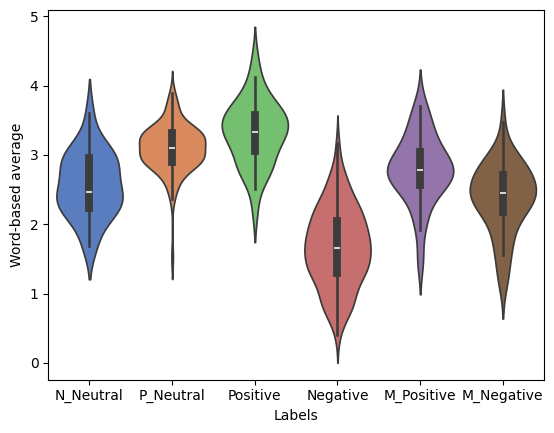

In [7]:
sns.violinplot(x="annotation_utt", y="word_avg", data=df_word, palette='muted')
plt.xlabel("Labels")
plt.ylabel("Word-based average")
plt.show()

## Character-based length avg

Average based on calculation of no. of characters in individual sentences

In [7]:
df1["char_length"] = df1["text_sent"].apply(len)
char_avg = (
    df1.groupby('ID')
    .apply(lambda x: (x["annotation_sent"] * x["char_length"]).sum() / x["char_length"].sum())
    .reset_index(name='char_avg')
)

df1 = df1.merge(char_avg, on='ID')

df_char = df1.drop_duplicates(subset=['ID']).reset_index()
mae = mean_absolute_error(df_char['annotation_utt_score'], df_char['char_avg'])

print(f"Mean Absolute Error (MAE): {mae}")

Mean Absolute Error (MAE): 1.0504567297120808


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1670/1040012026.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1.groupby('ID')


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1670/1385954366.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="annotation_utt_score", y="char_avg", data=df_char, palette='muted')


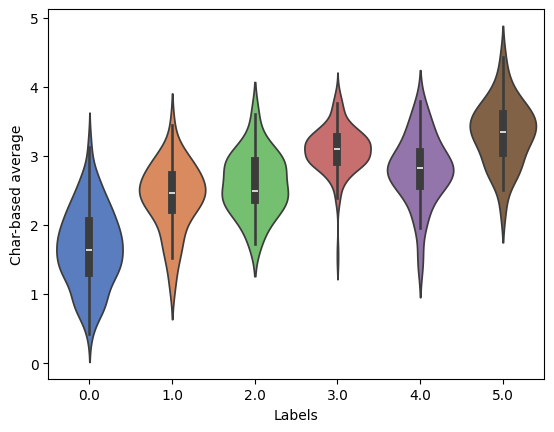

In [8]:
sns.violinplot(x="annotation_utt_score", y="char_avg", data=df_char, palette='muted')
plt.xlabel("Labels")
plt.ylabel("Char-based average")
plt.show()

## Additional feature building

Adding features for ML methods testing

In [9]:
columns = ['ID', 'annotation_sent', 'annotation_utt_score', 'count', 'char_length', 'char_avg']
df1 = df1[columns]
aggregation = df1.groupby('ID')['annotation_sent'].agg(
    mean = 'mean',
    median = 'median'
)

df1 = df1.merge(aggregation, on='ID')
df1['sum'] = df1.groupby('ID')['char_length'].transform('sum')
df1['Q1'] = df1.groupby('ID')['annotation_sent'].transform(lambda x: x.quantile(0.25))
df1['Q3'] = df1.groupby('ID')['annotation_sent'].transform(lambda x: x.quantile(0.75))
df1 = df1.drop(columns=['char_length'])
df1.head()

,ID,annotation_sent,annotation_utt_score,count,char_avg,mean,median,sum,Q1,Q3
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,2.240412,2.0,3,2.803708,2.838881,2.636969,122,2.438690,3.138115
1,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,2.636969,2.0,3,2.803708,2.838881,2.636969,122,2.438690,3.138115
2,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,3.639261,2.0,3,2.803708,2.838881,2.636969,122,2.438690,3.138115
3,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,4.084590,3.0,3,3.265325,3.491818,3.340636,88,3.195431,3.712613
4,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,3.340636,3.0,3,3.265325,3.491818,3.340636,88,3.195431,3.712613


In [10]:
data = df1.drop_duplicates(subset=['ID']).reset_index(drop=True)
data.head()

,ID,annotation_sent,annotation_utt_score,count,char_avg,mean,median,sum,Q1,Q3
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,2.240412,2.0,3,2.803708,2.838881,2.636969,122,2.438690,3.138115
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,4.084590,3.0,3,3.265325,3.491818,3.340636,88,3.195431,3.712613
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.ana.u178,4.084590,5.0,15,3.044246,3.235311,3.166192,2442,2.545302,3.812141
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.ana.u276,3.971972,0.0,32,1.788266,1.978221,1.869849,3646,0.537923,2.955510
4,ParlaMint-SI_2021-10-18-SDZ8-Redna-26.ana.u273,1.713008,0.0,19,1.376532,1.879965,2.262624,2159,0.367626,2.710190


## ML method

LinearSVR and Random Forest models

In [11]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestRegressor


# Features (count, mean, median, sum, character-based average, Q1, Q2)
X = data[['count', 'sum', 'mean', 'median', 'char_avg', 'Q1', 'Q3']]
y = data['annotation_utt_score']

print(X)
print(y)

     count   sum      mean    median  char_avg        Q1        Q3
0        3   122  2.838881  2.636969  2.803708  2.438690  3.138115
1        3    88  3.491818  3.340636  3.265325  3.195431  3.712613
2       15  2442  3.235311  3.166192  3.044246  2.545302  3.812141
3       32  3646  1.978221  1.869849  1.788266  0.537923  2.955510
4       19  2159  1.879965  2.262624  1.376532  0.367626  2.710190
..     ...   ...       ...       ...       ...       ...       ...
543     23  1838  2.222924  2.064153  1.989299  0.946307  3.392206
544      9   500  2.475496  2.976959  1.996089  2.023110  3.067105
545      9  1598  2.330899  2.520191  1.686053  1.307246  3.397097
546     15  2701  3.167355  3.063763  3.017512  2.782476  3.621196
547      4   184  3.084250  3.250649  2.634149  2.759999  3.574899

[548 rows x 7 columns]
0      2.0
1      3.0
2      5.0
3      0.0
4      0.0
      ... 
543    0.0
544    0.0
545    0.0
546    1.0
547    3.0
Name: annotation_utt_score, Length: 548, dtype: flo

### Train, development and test dataset

Manual split of the sentiment annotation data (n=800) into tranining (n=400) and developmental dataset (n=400). 

Additional 200 instances were reserved for a holdout testing set (../Dataset/Test_data.csv); 

The evaluation of methods and models on unseen testing instances is avalable in a spearate Jupyter Notebook (Methods_evaluation.ipynb). 

In [12]:
X_train, X_test = X[:400], X[400:]
y_train, y_test = y[:400], y[400:]

##SVR
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('svc', LinearSVR(max_iter=10000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)

MAE: 0.6792731285550804


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1670/3330685900.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df2,x='true',y='pred', palette='pastel')


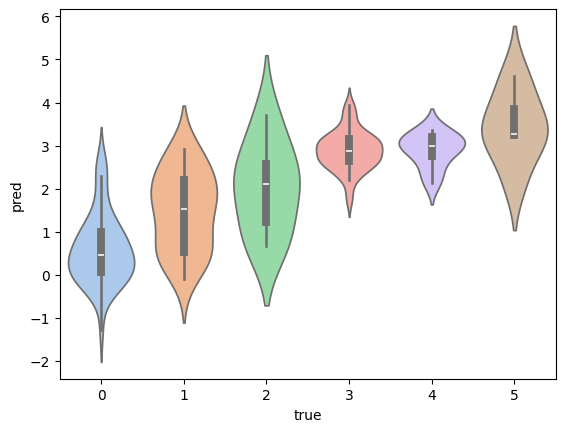

In [13]:
def violin(X_true,X_pred):
  df2=pd.DataFrame({'true':X_true,'pred':X_pred})
  df2['true']=pd.Categorical(df2['true'],categories=[0,1,2,3,4,5])
  sns.violinplot(data=df2,x='true',y='pred', palette='pastel')

violin(y_test, y_pred)

In [14]:
y_pred = cross_val_predict(pipeline, X, y, cv=5)
mae = mean_absolute_error(y, y_pred)
print('MAE:', mae)

MAE: 0.7672247059217551


In [17]:
import joblib

joblib.dump(pipeline, '../Models/LinearSVR_model.pkl')

['../Models/LinearSVR_model.pkl']

## Random forest

MAE: 0.6002919708029197


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_3375/3330685900.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df2,x='true',y='pred', palette='pastel')


,ID,annotation_sent,annotation_utt_score,count,char_avg,mean,median,sum,Q1,Q3,rf_predictions
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,2.240412,2.0,3,2.803708,2.838881,2.636969,122,2.438690,3.138115,2.86
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,4.084590,3.0,3,3.265325,3.491818,3.340636,88,3.195431,3.712613,3.00
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.ana.u178,4.084590,5.0,15,3.044246,3.235311,3.166192,2442,2.545302,3.812141,3.60
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.ana.u276,3.971972,0.0,32,1.788266,1.978221,1.869849,3646,0.537923,2.955510,0.09
4,ParlaMint-SI_2021-10-18-SDZ8-Redna-26.ana.u273,1.713008,0.0,19,1.376532,1.879965,2.262624,2159,0.367626,2.710190,0.10
...,...,...,...,...,...,...,...,...,...,...,...
543,ParlaMint-SI_2021-03-04-SDZ8-Izredna-64.ana.u150,4.312339,0.0,23,1.989299,2.222924,2.064153,1838,0.946307,3.392206,0.82
544,ParlaMint-SI_2013-11-19-SDZ6-Redna-19.ana.u346,3.709246,0.0,9,1.996089,2.475496,2.976959,500,2.023110,3.067105,0.68
545,ParlaMint-SI_2020-11-16-SDZ8-Izredna-48.ana.u284,3.626231,0.0,9,1.686053,2.330899,2.520191,1598,1.307246,3.397097,0.34
546,ParlaMint-SI_2014-03-03-SDZ6-Redna-22.ana.u242,3.710418,1.0,15,3.017512,3.167355,3.063763,2701,2.782476,3.621196,3.76


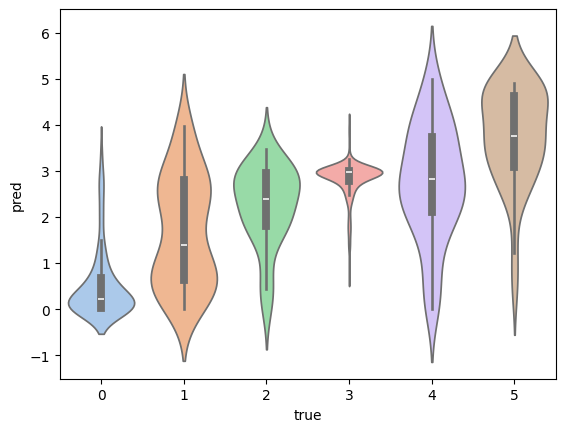

In [16]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
y_pred = cross_val_predict(rf, X, y, cv=5)
mae = mean_absolute_error(y, y_pred)
data['rf_predictions'] = y_pred


print('MAE:', mae)
violin(y, y_pred)
data

### Fitting RF model on the training data

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

rf.fit(X_train, y_train)
test_predictions = rf.predict(X_test)
mse = mean_squared_error(y_test, test_predictions)
r2 = r2_score(y_test,test_predictions)
mae = mean_absolute_error(y_test, test_predictions)

print(f"Performance: MAE = {mae:.4f}, MSE = {mse:.4f}, R2 = {r2:.4f}")


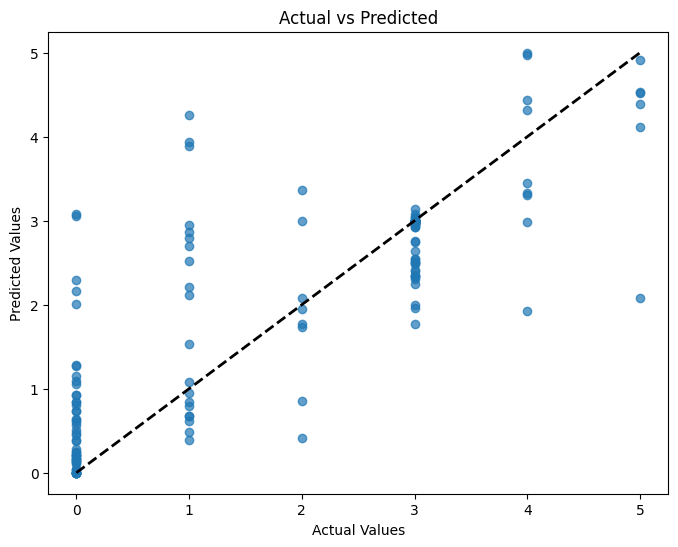

In [18]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # 45-degree line
plt.title("Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

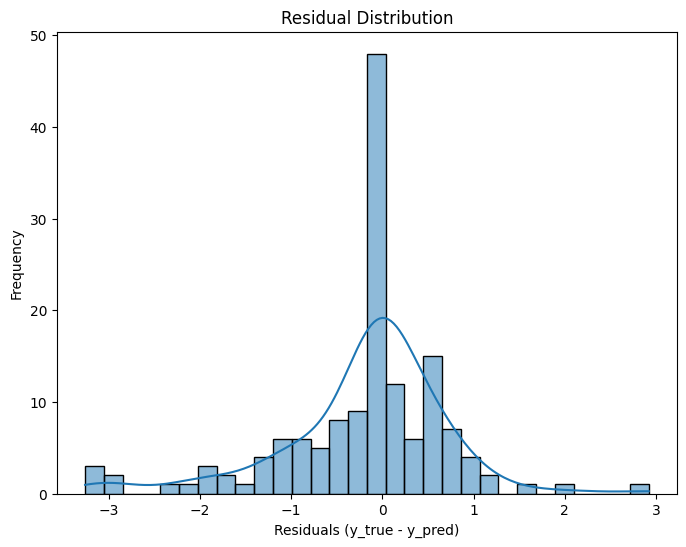

In [19]:
residuals = y_test - test_predictions
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals (y_true - y_pred)")
plt.ylabel("Frequency")
plt.show()

In [24]:
print(f"Range of Actual Values: {y_test.min()} to {y_test.max()}")
print(f"Range of Predicted Values: {test_predictions.min()} to {test_predictions.max()}")

Range of Actual Values: 0.0 to 5.0
Range of Predicted Values: 0.0 to 5.0


In [25]:
joblib.dump(rf, '../Models/RF_model.pkl')

['../Models/RF_model.pkl']

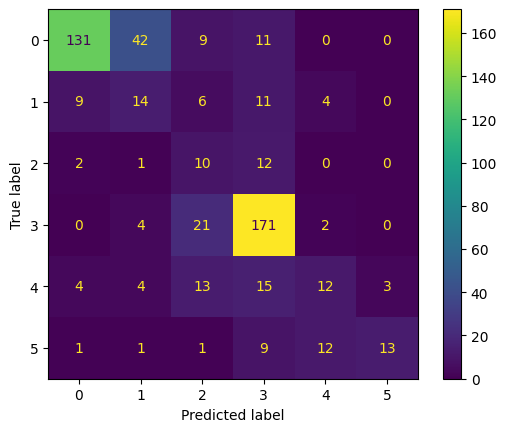

In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_clip = np.clip(np.round(y_pred), 0, 5).astype(int)
cm = confusion_matrix(y, y_pred_clip)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.savefig('../Figures/RandomForest_6categories_CM.png', dpi=300)
plt.show()

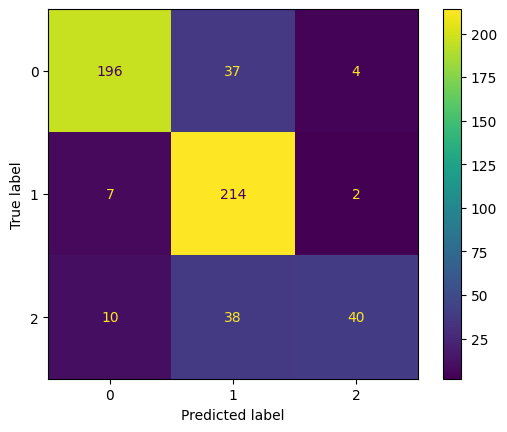

In [27]:
y_3 = np.floor_divide(y, 2)
y_pred_3 = np.floor_divide(y_pred_clip, 2)
#print(y_pred_3)
cm = confusion_matrix(y_3, y_pred_3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.savefig('../Figures/RandomForest_3categories_CM.png', dpi=300)
plt.show()

### RF CM vs Heuristic CM

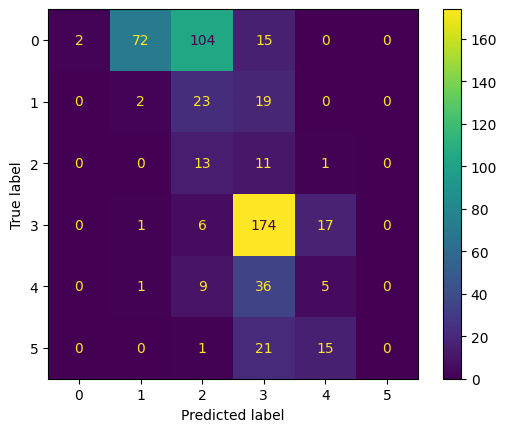

In [28]:
heuristic = data['char_avg']
X_heuristic = np.clip(np.round(heuristic), 0, 5).astype(int)
cm = confusion_matrix(y, X_heuristic)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.savefig('../Figures/Heuristic_6categories_CM.png', dpi=300)
plt.show()

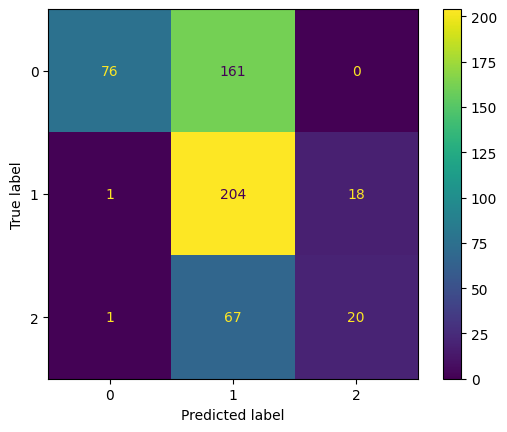

In [29]:
X_heuristic_3 = np.floor_divide(X_heuristic, 2)
cm = confusion_matrix(y_3, X_heuristic_3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.savefig('../Figures/Heuristic_3categories_CM.png', dpi=300)
plt.show()